In [ ]:
!pip -q install -U datasets sentence-transformers scikit-learn umap-learn \
    pandas matplotlib seaborn wordcloud 2>/dev/null

import warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="deep")

SAMPLE_SIZE = 4000
RANDOM_STATE = 42
EMB_MODEL   = "sentence-transformers/all-MiniLM-L6-v2"

In [ ]:
from datasets import load_dataset

ds = load_dataset("amphora/ResearchMath-14k", split="test")
df = ds.to_pandas()
print("Rows:", len(df))
print("Columns:", list(df.columns))
df.head(3)

TEXT_COL = "self_contained_problem"
df = df[df[TEXT_COL].astype(str).str.len() > 20].reset_index(drop=True)

In [ ]:
print("\n--- open_status distribution ---")
print(df["open_status"].value_counts(dropna=False))

print("\n--- taxonomy_level_1 (math fields) ---")
print(df["taxonomy_level_1"].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

df["open_status"].value_counts().plot(
    kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Problem status"); axes[0].tick_params(axis="x", rotation=30)

df["taxonomy_level_1"].value_counts().plot(
    kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("Top-level math field"); axes[1].invert_yaxis()

df["doc_len"] = df[TEXT_COL].str.split().apply(len)
axes[2].hist(df["doc_len"].clip(upper=400), bins=40, color="indianred")
axes[2].set_title("Problem length (words, clipped @400)")
plt.tight_layout(); plt.show()

ct = pd.crosstab(df["taxonomy_level_1"], df["open_status"], normalize="index")
plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="rocket_r")
plt.title("Fraction of each status within each field")
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

def top_terms_per_group(frame, group_col, text_col, k=8):
    out = {}
    for g, sub in frame.groupby(group_col):
        if len(sub) < 20:
            continue
        vec = TfidfVectorizer(max_features=3000, stop_words="english",
                              ngram_range=(1, 2), min_df=3)
        X = vec.fit_transform(sub[text_col])
        scores = np.asarray(X.mean(axis=0)).ravel()
        terms = np.array(vec.get_feature_names_out())
        out[g] = terms[scores.argsort()[::-1][:k]].tolist()
    return out

for field, terms in top_terms_per_group(df, "taxonomy_level_1", TEXT_COL).items():
    print(f"\n{field:35s} -> {', '.join(terms)}")

In [ ]:
import torch
from sentence_transformers import SentenceTransformer

work = df.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True) \
       if SAMPLE_SIZE else df.copy()

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Embedding", len(work), "problems on", device)

model = SentenceTransformer(EMB_MODEL, device=device)
emb = model.encode(work[TEXT_COL].tolist(),
                   batch_size=64, show_progress_bar=True,
                   normalize_embeddings=True)
print("Embedding matrix:", emb.shape)

try:
    import umap
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1,
                        metric="cosine", random_state=RANDOM_STATE)
    coords = reducer.fit_transform(emb)
    method = "UMAP"
except Exception as e:
    from sklearn.decomposition import PCA
    coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(emb)
    method = "PCA (UMAP unavailable)"

work["x"], work["y"] = coords[:, 0], coords[:, 1]
plt.figure(figsize=(13, 9))
sns.scatterplot(data=work, x="x", y="y", hue="taxonomy_level_1",
                s=12, alpha=0.7, linewidth=0)
plt.title(f"{method} map of ResearchMath problems, colored by field")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

n_fields = work["taxonomy_level_1"].nunique()
km = KMeans(n_clusters=n_fields, random_state=RANDOM_STATE, n_init=10)
work["cluster"] = km.fit_predict(emb)

ari = adjusted_rand_score(work["taxonomy_level_1"], work["cluster"])
nmi = normalized_mutual_info_score(work["taxonomy_level_1"], work["cluster"])
print(f"KMeans vs taxonomy_level_1 -> ARI={ari:.3f}  NMI={nmi:.3f}")
print("(higher = embeddings rediscover the human field labels on their own)")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 10.2 MB/s eta 0:00:00


README.md:   0%|          | 0.00/3.30k [00:00<?, ?B/s]

data/train.jsonl:   0%|          | 0.00/47.9M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/14056 [00:00<?, ? examples/s]

Rows: 14056
Columns: ['paper_id', 'question_link', 'original_question', 'self_contained_problem', 'taxonomy_level_1', 'taxonomy_level_2', 'taxonomy_level_3', 'open_status', 'status_search_result', 'status_evidence', 'status_evidence_urls']

--- open_status distribution ---
open_status
open                8313
unknown             2489
partially_solved    2083
solved              1171
Name: count, dtype: int64

--- taxonomy_level_1 (math fields) ---
taxonomy_level_1
Analysis, PDEs, and Dynamics              3197
Mathematical Physics                      2031
Discrete Mathematics and Combinatorics    1897
Geometry and Topology                     1846
Algebra and Representation Theory         1289
Applied and Computational Mathematics      839
Number Theory                              806
Theoretical Computer Science               749
Probability, Statistics, and ML            636
Logic and Foundations                      455
Other / Cross-disciplinary                 311
Name: count, d

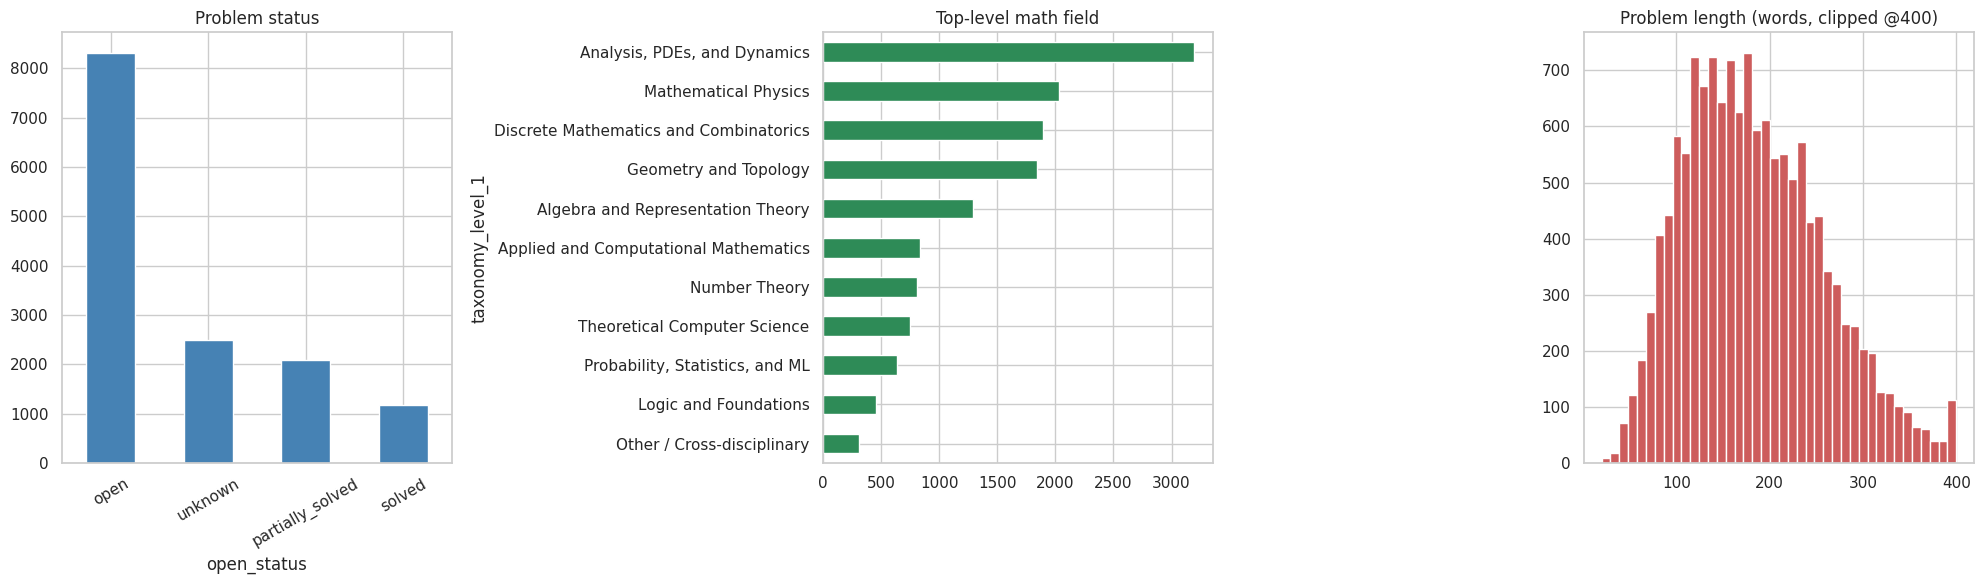

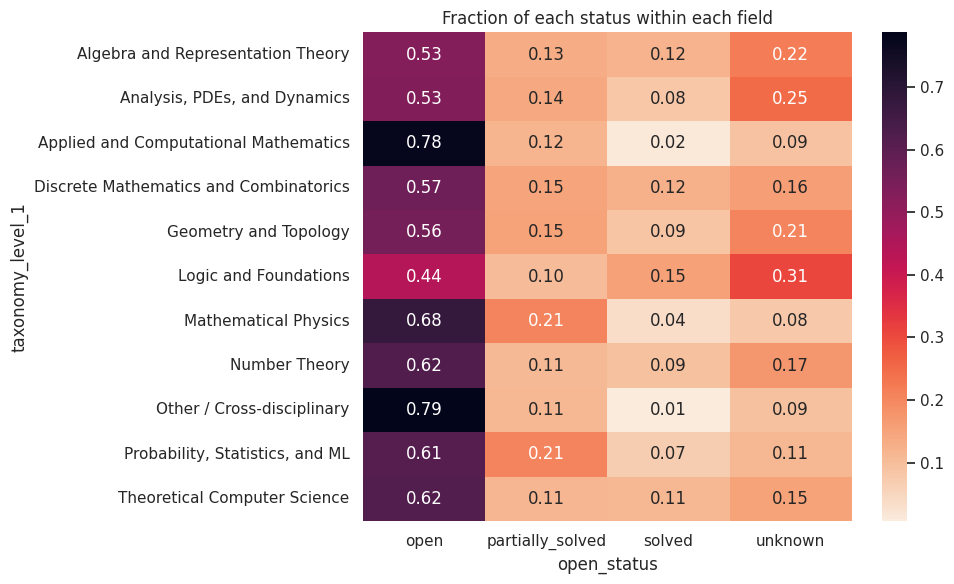


Algebra and Representation Theory   -> group, mathbb, let, mathrm, finite, mathcal, gamma, dots

Analysis, PDEs, and Dynamics        -> mathbb, omega, let, infty, mathcal, lambda, space, alpha

Applied and Computational Mathematics -> mathbb, mathcal, time, model, let, set, problem, function

Discrete Mathematics and Combinatorics -> graph, mathbb, let, set, vertices, integer, finite, vertex

Geometry and Topology               -> mathbb, mathcal, let, mathrm, space, gamma, subset, smooth

Logic and Foundations               -> mathcal, omega, set, mathbb, lambda, finite, mathrm, order

Mathematical Physics                -> energy, state, field, mathcal, quantum, model, mass, density

Number Theory                       -> mathbb, integer, positive, let, prime, number, integers, ge

Other / Cross-disciplinary          -> language, mass, determine, identify, star, stellar, galaxies, human

Probability, Statistics, and ML     -> mathcal, mathbb, let, infty, time, distribution, random, 

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

In [ ]:
from sentence_transformers import util

def search(query, k=5):
    q = model.encode([query], normalize_embeddings=True)
    sims = util.cos_sim(q, emb)[0].cpu().numpy()
    idx = sims.argsort()[::-1][:k]
    print(f'\n=== Query: "{query}" ===')
    for rank, i in enumerate(idx, 1):
        row = work.iloc[i]
        print(f"\n[{rank}] sim={sims[i]:.3f} | {row['taxonomy_level_1']} "
              f"| status={row['open_status']}")
        print("   ", row[TEXT_COL][:260].replace("\n", " "), "...")

search("rational points on hyperelliptic curves")
search("multiplicativity of maximal output p-norm of a quantum channel")

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y = work["open_status"].values
Xtr, Xte, ytr, yte = train_test_split(
    emb, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

clf = LogisticRegression(max_iter=2000, class_weight="balanced", C=2.0)
clf.fit(Xtr, ytr)
pred = clf.predict(Xte)

print("\n=== open_status classifier (embeddings + logistic regression) ===")
print(classification_report(yte, pred))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    yte, pred, ax=ax, cmap="Blues", xticks_rotation=45,
    normalize="true", values_format=".2f")
ax.set_title("open_status confusion matrix (row-normalized)")
plt.tight_layout(); plt.show()

sims = util.cos_sim(emb, emb).cpu().numpy()
np.fill_diagonal(sims, 0)
i, j = np.unravel_index(sims.argmax(), sims.shape)
print(f"\nMost similar pair (cos={sims[i, j]:.3f}):")
for n in (i, j):
    print(f"\n  paper_id={work.iloc[n]['paper_id']} | "
          f"{work.iloc[n]['taxonomy_level_1']}")
    print("   ", work.iloc[n][TEXT_COL][:240].replace("\n", " "), "...")

print("\nDone. Set SAMPLE_SIZE=None at the top to run on the full 14.1k rows.")